# Demonstration of the `gsf` package


This notebook runs **GalacticStructureFinder** on the bundled example galaxy (`tests/sim1`) for the simplest case of **two kinematic components**, and shows the result: the face-on/edge-on moment maps of the named components, and a table of their physical properties.

The first step computes the gravitational potential at every stellar particle by direct two-body summation, which is the slowest part of the run; exporting `OMP_NUM_THREADS` (up to the number of cores on your machine) before starting Jupyter speeds it up considerably.


In [1]:
import os, glob, pickle
import numpy as np
from IPython.display import Image, HTML, display
import gsf

# Locate the bundled example galaxy (works whether this notebook runs from the
# repository root or from the notebooks/ directory).
sim_dir = next(p for p in ('tests/sim1', '../tests/sim1', '../../tests/sim1')
               if os.path.exists(os.path.join(p, 'sim1.halo_1.star.dat')))
star = os.path.join(sim_dir, 'sim1.halo_1.star.dat')
gas  = os.path.join(sim_dir, 'sim1.halo_1.gas.dat')
dark = os.path.join(sim_dir, 'sim1.halo_1.dark.dat')

out_dir = 'demo_output/'
os.makedirs(out_dir, exist_ok=True)

# Decompose the galaxy into two components. This runs the whole pipeline:
# potential -> derived quantities -> GMM clustering -> moment maps -> naming.
gsf.gsf(star, gas, dark, number_of_clusters=2, out_dir=out_dir, plot=False, verbose=False)


Generate the two potential files that the clustering algorithm needs.
Make sure the positions and velocities are in the c.o.m. reference system of the stars
Find out the virial radius as the maximum radius of dark matter particles


Define the maximum and minimum radius radii for the particles to be considered for the definition of the equatorial plane
Compute the angular momentum of stars with 0.30 < r/kpc < 49.97
test that the rotation matrix works as intented...
This ratio should be 1: Jz/J = 1.0000
Constructing the jc-E mapping considering the halo in isolation and recomputing the potential... 


Runtime of midplane_potential: 0:00:03.750
total number of stellar particles = 74661
Computing the contribution of all the stars to the gravitational potential at all stellar particles positions...


... took 0:00:08.253
Computing the contribution of all the gas to the gravitational potential at all stellar particles positions...
total number of gas particles = 8758


... took 0:00:01.002
Computing the contribution of all the dark matter to the gravitational potential at all stellar particles positions...
total number of dark matter particles = 928083


...

/home/aura/miniforge3/envs/gsf-test/lib/python3.12/site-packages/gsf/doplots.py:928: RuntimeWarning: invalid value encountered in divide
  vlos = vlos/sdens
/home/aura/miniforge3/envs/gsf-test/lib/python3.12/site-packages/gsf/doplots.py:930: RuntimeWarning: invalid value encountered in divide
  vlos2 = vlos2/sdens


/home/aura/miniforge3/envs/gsf-test/lib/python3.12/site-packages/gsf/doplots.py:980: RuntimeWarning: invalid value encountered in divide
  vlos = vlos/sdens
/home/aura/miniforge3/envs/gsf-test/lib/python3.12/site-packages/gsf/doplots.py:982: RuntimeWarning: invalid value encountered in divide
  vlos2 = vlos2/sdens


I will merge all moments plots in one and erase the individual ones.
The components are sorted by their mass fractions from bottom to top.


Load the deco file.


Total runtime: 0:03:04.127
Finish


## Component maps

For every component `gsf` produces, from left to right, the face-on surface mass density, the edge-on surface mass density, and the edge-on line-of-sight velocity. The rows are stacked into a single mosaic (the whole galaxy on top, then the components ordered by mass fraction), with each component labelled by the physical name assigned by `tag_components`.


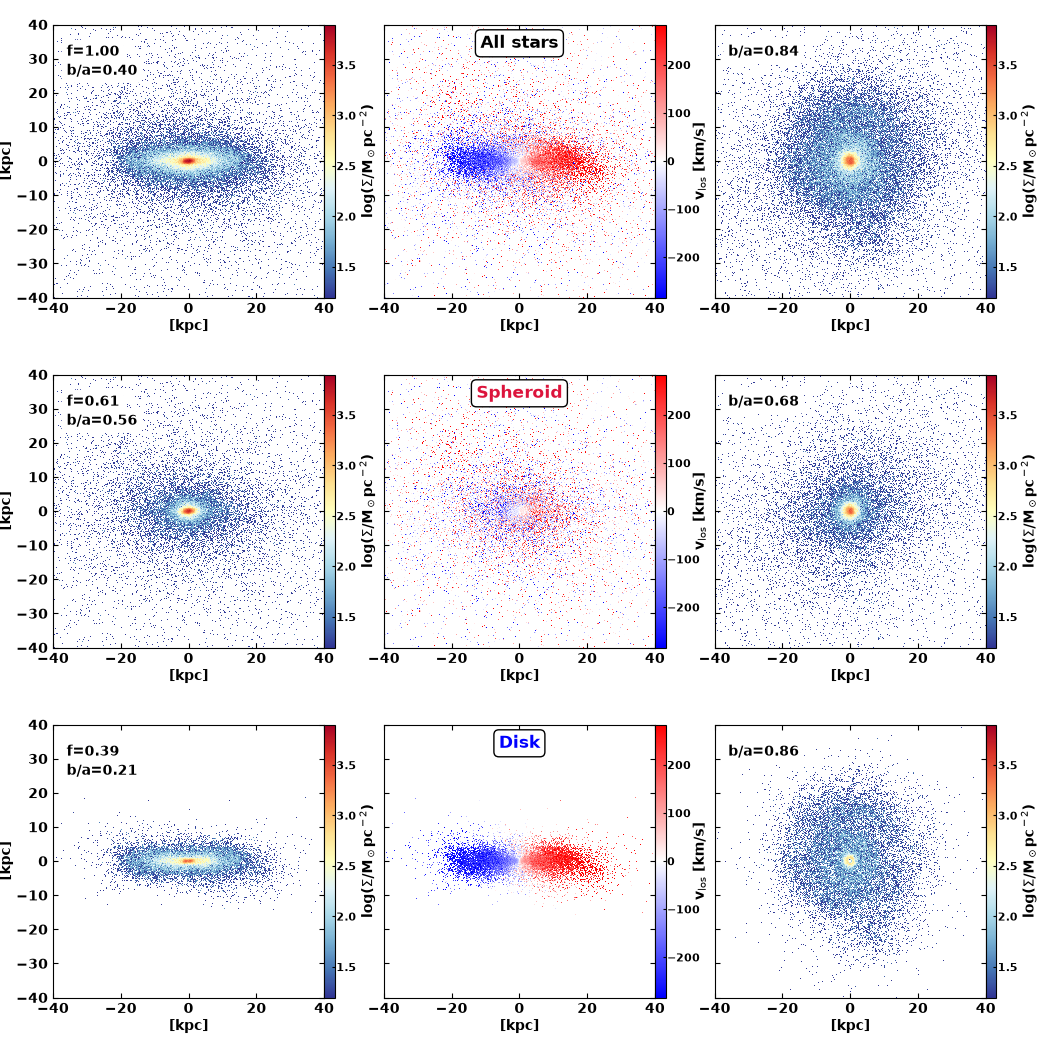

In [2]:
# The two-inclination mosaic written by tag_components -> plot_2inclinations_moment_maps.
mosaic = sorted(glob.glob(out_dir + '*_2inc_mosaic.png'))[0]
display(Image(filename=mosaic))


## Component properties

`gsf` also writes a per-model summary (`*summary.dat`) with the mass-weighted properties of each component. Below we load it and the component names and lay out the main quantities: mass fraction, the equatorial-plane asymmetry `b/a`, the flatness `xi = 2(1 - c/a) - 1`, and the mass-weighted median (with 16th/84th percentiles) of the 3D radius, rotational velocity, vertical-velocity dispersion, and normalized binding energy.


In [3]:
summ = pickle.load(open(glob.glob(out_dir + '*summary.dat')[0], 'rb'))
res, gl = summ['result'], summ['result_global']
names = pickle.load(open(glob.glob(out_dir + '*_tags.dat')[0], 'rb'))['tags']

def _s(x):
    return float(np.ravel(np.asarray(x))[0])   # robust scalar extraction

def pm(med, lo, hi, fmt='%.2f'):
    return '%s (+%s / -%s)' % (fmt % med, fmt % (hi - med), fmt % (med - lo))

def quantities(kind, j=None):
    if kind == 'all':
        a, b, c = _s(gl['a']), _s(gl['b']), _s(gl['c'])
        massfrac = 1.0
        get = lambda feat, pp: _s(gl[feat][pp])
    else:
        a, b, c = _s(res['a'][j]), _s(res['b'][j]), _s(res['c'][j])
        massfrac = _s(res['total_mass'][j]) / _s(gl['total_mass'])
        get = lambda feat, pp: _s(res[feat][pp][j])
    return {
        'f = M/M*':      '%.2f' % massfrac,
        'b/a':           '%.2f' % (b / a),
        'flatness xi':   '%.2f' % (2 * (1 - c / a) - 1),
        'r [kpc]':       pm(get('r3', 50), get('r3', 16), get('r3', 84)),
        'v_phi [km/s]':  pm(get('vphi', 50), get('vphi', 16), get('vphi', 84), '%.0f'),
        'sigma(v_z) [km/s]': '%.0f' % ((get('vz', 84) - get('vz', 16)) / 2),
        'e/max|e|':      pm(get('e', 50), get('e', 16), get('e', 84)),
    }

columns = [('All', quantities('all'))] + [(names[j], quantities('comp', j)) for j in range(len(names))]
rows = list(columns[0][1].keys())

th = "style='padding:4px 12px;border-bottom:2px solid #444'"
td = "style='padding:4px 12px;text-align:center'"
tl = "style='padding:4px 12px;text-align:left'"
html = "<table style='border-collapse:collapse;font-family:sans-serif'>"
html += '<tr><th %s>property</th>' % tl + ''.join('<th %s>%s</th>' % (th, n) for n, _ in columns) + '</tr>'
for r in rows:
    html += '<tr><td %s><b>%s</b></td>' % (tl, r)
    html += ''.join('<td %s>%s</td>' % (td, d[r]) for _, d in columns)
    html += '</tr>'
html += '</table>'
HTML(html)


property,All,Disk,Spheroid
f = M/M*,1.00,0.39,0.61
b/a,0.92,0.94,0.46
flatness xi,-0.17,0.43,0.21
r [kpc],12.45 (+63.47 / -10.54),10.78 (+8.53 / -7.46),16.14 (+106.89 / -14.58)
v_phi [km/s],123 (+150 / -169),241 (+67 / -76),28 (+126 / -123)
sigma(v_z) [km/s],93,56,128
e/max|e|,-0.60 (+0.30 / -0.26),-0.62 (+0.10 / -0.17),-0.56 (+0.35 / -0.33)


## Full LaTeX table (for publication)

For direct inclusion in a paper, `gsf` also writes the complete, richer summary table as a ready-to-`\input` LaTeX file (`*table.tex`). Its contents:


In [4]:
tex = glob.glob(out_dir + '*table.tex')[0]
print('Written to:', tex, '\n')
print(open(tex).read())


Written to: demo_output/sim1.halo_1.star.gmm_on_jzjcjpjce.scikit_gmm_full_2clusters_whitetable.tex 

\begin{table}[h!]
\centering
\begin{tabular}{cccc}
\hline
Property & All & Disk & Spheroid\\ 
\hline
$M$ [10$^{\rm 10}$M$_{\rm\odot}$] & 8.91 & 3.61 & 5.29\\ 
$f$=$\frac{M}{M_{\rm *}}$ & 1.00 & 0.41 & 0.59\\ 
$b/a$ & 0.92 & 0.93 & 0.80\\ 
$\xi$ & -0.17 & 0.45 & -0.41\\ 
$\kappa$ & -0.55 & 0.58 & -1.22\\ 
$\rm\sigma$($z$) [kpc] & 5.46 & 1.90 & 16.21\\ 
$\rm\sigma$($v_z$) [km/s] & 92 & 56 & 129\\ 
$\rm\sigma$($v_R$) [km/s] & 138 & 81 & 194\\ 
$r$ [kpc] & 12.45$^{\rm +63.47}_{\rm -10.54}$ & 10.71$^{\rm +8.58}_{\rm -7.53}$ & 16.64$^{\rm +108.95}_{\rm -15.08}$\\ 
$R$ [kpc] & 11.57$^{\rm +51.08}_{\rm -9.86}$ & 10.50$^{\rm +8.43}_{\rm -7.40}$ & 13.97$^{\rm +91.22}_{\rm -12.62}$\\ 
$v_{\rm\phi}$ [km/s] & 123$^{\rm +149}_{\rm -168}$ & 240$^{\rm +67}_{\rm -76}$ & 24$^{\rm +119}_{\rm -122}$\\ 
$age$ [Gyr] & 10.38$^{\rm +2.06}_{\rm -3.49}$ & 8.31$^{\rm +3.27}_{\rm -2.09}$ & 11.61$^{\rm +0.98}_{\rm 